<a href="https://colab.research.google.com/github/GitGirlie27/urdu-ocr-codesaviours-si26-Amna/blob/main/SI26_Week2_Amna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMAGE PREPROCESSING USING URDU OCR DATASET**

# *Install Packages*

In [1]:
!pip install opencv-python-headless pillow

In [2]:
import zipfile

zip_path = "/content/Urdu OCR Dataset Updated.zip"
extract_path = "/content/Urdu_OCR_Dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


# *Install Libraries*

In [3]:
import cv2
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt
print('Libraries loaded successfully!')

Libraries loaded successfully!


# *Image Preprocessing Techniques*

In [6]:
import cv2
import numpy as np
import os

def preprocess_image(image_path, save_path):

    # Read image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Could not load: {image_path}")
        return None

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize only if image is very small
    h, w = gray.shape

    if h < 600:
        scale = 2
        gray = cv2.resize(
            gray,
            None,
            fx=scale,
            fy=scale,
            interpolation=cv2.INTER_CUBIC
        )

    # Contrast enhancement (works well for yellow pages and faded scans)
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(gray)

    # Noise removal
    denoised = cv2.fastNlMeansDenoising(
        enhanced,
        None,
        h=12
    )

    # Adaptive threshold
    binary = cv2.adaptiveThreshold(
        denoised,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        15
    )

    # Morphological opening
    kernel = np.ones((2,2), np.uint8)

    cleaned = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel
    )

    # Save
    cv2.imwrite(save_path, cleaned)

    return cleaned

# *Process Entire Dataset*

In [7]:
import glob
import os

# Input and output folders
input_folder = "/content/Urdu_OCR_Dataset/Urdu OCR Dataset"
output_folder = "/content/processed"

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Read all PNG images
image_paths = sorted(glob.glob(os.path.join(input_folder, "*.png")))

print(f"Total PNG images found: {len(image_paths)}")

# Process each image
for image_path in image_paths:
    filename = os.path.basename(image_path)  # Keep the original filename
    save_path = os.path.join(output_folder, filename)

    preprocess_image(image_path, save_path)

print("Preprocessing completed successfully!")

Total PNG images found: 219
Preprocessing completed successfully!


# *Display Image Before and After Processing*

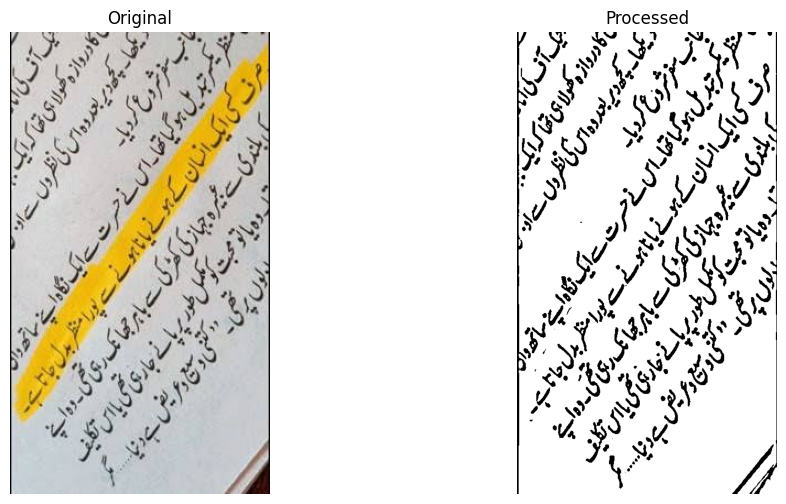

In [28]:
import cv2
import matplotlib.pyplot as plt

filename = "219.png"

original = cv2.imread(f"/content/Urdu_OCR_Dataset/Urdu OCR Dataset/{filename}")
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

processed = cv2.imread(
    f"/content/processed/{filename}",
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed, cmap="gray")
plt.title("Processed")
plt.axis("off")

plt.show()

# *Installing Tesseract Packages*

In [9]:
!apt-get install -y tesseract-ocr tesseract-ocr-urd
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-urd
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 1,000 kB of archives.
After this operation, 1,413 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-urd all 1:4.00~git30-7274cfa-1.1 [1,000 kB]
Fetched 1,000 kB in 2s (411 kB/s)
Selecting previously unselected package tesseract-ocr-urd.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-urd_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...


# *Testing Tesseract on Urdu Images*

In [10]:

from PIL import Image
import pytesseract

# Path to processed images
test_images = sorted(glob.glob('/content/processed/*.png'))[:5]

print("=== Tesseract Results on Urdu Images ===\n")

for img_path in test_images:
    img = Image.open(img_path)

    # OCR using the Urdu language model
    result = pytesseract.image_to_string(img, lang='urd')

    print(f"Image: {img_path}")
    print(f"Tesseract output:\n{result}")
    print("-" * 50)

=== Tesseract Results on Urdu Images ===

Image: /content/processed/0.png
Tesseract output:
اور بنوں ( نما حر جنپ , اے الف فی ) بوں میں اثوام مب راشییل اور

--------------------------------------------------
Image: /content/processed/1.png
Tesseract output:
کے سا تھ میق علا تے کے عوام نے می وکس

--------------------------------------------------
Image: /content/processed/10.png
Tesseract output:
نے مھ وکا سکیلوڈشی ےنگ سراف مظاہر دہکا۔ مظائ من نے

--------------------------------------------------
Image: /content/processed/100.png
Tesseract output:
خر کونمام پکما اسسلا مم کے نا
ا1 ص ص ە-- م کے نام

--------------------------------------------------
Image: /content/processed/101.png
Tesseract output:
رای ِ وزا فلل کر کے ونیک میں اسسلا مکی

--------------------------------------------------


# *• What was the actual Urdu text in the image and What did Tesseract output? also, What went wrong? (wrong characters, missing words, gibberish?)*

# | **Image**|**Tesseract Output**         |  **Actual Urdu Text**                                                 | **What Went Wrong?**                                                                                                                                                                  |

# | 0.png   | پشاور، بنوں (نمائندہ جنگ، اے ایف پی) |بنوں میں اقوام میراخیل اور |                    ای کی رر  | Tesseract recognized only a few unrelated characters. Most of the sentence is missing, and the output is incomplete and meaningless.                                              |
# | 1.png   | اسکے ساتھ ملحقہ علاقے کے عوام نے بجلی و گیس |               ءا ملا ےار بھی                         | Several words are missing or incorrectly recognized. Characters are substituted, and the sentence does not match the original text.                                               |
# | 10.png  | نے بجلی و گیس کی لوڈ شیڈنگ کیخلاف مظاہرہ کیا۔ مظاہرین نے |                     کک کک ۸           | Almost the entire sentence is lost. The output consists of repeated characters and a number, making it meaningless.                                                                |
# | 100.png | نہیں آیا۔ آخر یہ کونسا مذہب ہے؟ کیا اسلام کے نام |                  راف وی اما                   | Only a few characters are recognized incorrectly. Most words are omitted, and the output bears little resemblance to the original sentence.                                        |
# | 101.png | پر ایسا گھناؤنا عمل کر کے دنیا بھر میں اسلام کی کرکے |ایا نان نی کے دا ریس الا مکی               | Some words are partially recognized, but many characters are incorrect, words are incomplete, and spacing is inaccurate. The sentence does not correctly represent the original text.|
